# Proyecto de Grado: IA al servicio de las comunidades
Maestría en Analítica para la Inteligencia de Negocios

**Nombres:** María Fernanda Izquierdo Aparicio & Ana María Ochoa Muñoz
**Fecha:** 17 de Marzo de 2025

Este modelo forma parte del proyecto de grado de la Maestría en Analítica para la Inteligencia de Negocios de la Pontificia Universidad Javeriana, enfocado en la aplicación de Inteligencia Artificial al servicio de las comunidades. Su objetivo es clasificar imágenes de plantas en función de su especie.

## 1. Importe de librerias

Se cargan las librerías necesarias para manipulación de datos, procesamiento de imágenes y modelado con redes neuronales. Algunas destacadas:

* Pandas y NumPy: Para manejo de datos.
* Matplotlib y Seaborn: Para visualización.
* OpenCV (cv2) y PIL (Image): Para procesamiento de imágenes.
* TensorFlow y Keras: Para construir y entrenar modelos de deep learning.

In [3]:
import json

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

import os
import zipfile
import shutil
import seaborn as sns
import datetime
import cv2


import keras
from keras import models
from keras import layers

import random

import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras import Layer
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.preprocessing import image
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.preprocessing.image import img_to_array, load_img
from tensorflow.keras.callbacks import ReduceLROnPlateau
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.optimizers import Adam


from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score

from PIL import Image  # Librería para abrir y manipular imágenes

# ignoring warnings
import warnings
warnings.simplefilter("ignore")

In [4]:
#Medir_tiempo_ejecucion():
inicio = datetime.datetime.now()
print(f"Inicio: {inicio.strftime('%Y-%m-%d %H:%M:%S.%f')}")

Inicio: 2025-04-04 16:45:19.815082


## 2. Importe de Datos
* Se importa un archivo CSV (Data_Final.csv) con el listado de imágenes y etiquetas.
* Se eliminan registros de la clase "Orange".
* Se divide el dataset en 80% entrenamiento - 20% prueba, asegurando balance entre clases con stratify.

In [8]:
def obtener_muestras_por_categoria(df, columna_categoria, num_muestras=1500):
    """
    Obtiene un número fijo de muestras por categoría de un DataFrame.

    Args:
        df (pd.DataFrame): El DataFrame original.
        columna_categoria (str): El nombre de la columna que contiene las categorías.
        num_muestras (int): El número de muestras a obtener por categoría.

    Returns:
        pd.DataFrame: Un nuevo DataFrame con el número especificado de muestras por categoría.
    """

    muestras_por_categoria = []
    for categoria in df[columna_categoria].unique():
        df_categoria = df[df[columna_categoria] == categoria]
        muestras_categoria = df_categoria.sample(n=min(num_muestras, len(df_categoria)), random_state=42)  # Usa sample para obtener muestras aleatorias
        muestras_por_categoria.append(muestras_categoria)

    df_muestras = pd.concat(muestras_por_categoria)
    return df_muestras

# Carga tu dataset
train = pd.read_csv('Data_Final.csv', sep=";")

# Obtén 1500 muestras por categoría
train = obtener_muestras_por_categoria(train, 'Planta', num_muestras=1500)

# Verifica el resultado
print(train['Planta'].value_counts())

Planta
Strawberry      1500
Grape           1500
Potato          1500
Corn_(maize)    1500
Tomato          1500
Pepper_bell     1500
Orange          1500
Apple           1500
Peach           1500
Yuca            1500
Name: count, dtype: int64


In [10]:
train.head()

,Carpeta,Nombre del archivo,Planta,Condición,Saludable,Planta_Estado
42054,Strawberry___Leaf_scorch,f1c2c618-1be3-4fa3-b3ed-b88ca37f3ade___RS_L.Sc...,Strawberry,Leaf_scorch,NO,Strawberry_sick
271,Strawberry___healthy,d451b14d-8338-47e7-9505-1797ae645742___RS_HL 1...,Strawberry,healthy,SI,Strawberry_healthy
42929,Strawberry___Leaf_scorch,ce4da8b3-1764-48f6-adbc-ee1cf266d34c___RS_L.Sc...,Strawberry,Leaf_scorch,NO,Strawberry_sick
42728,Strawberry___Leaf_scorch,5e4669c3-c980-4fb7-84ee-c2b92f55ac3d___RS_L.Sc...,Strawberry,Leaf_scorch,NO,Strawberry_sick
59,Strawberry___healthy,b938a735-b7a3-463d-b5b9-3bfd7041fe51___RS_HL 1...,Strawberry,healthy,SI,Strawberry_healthy


In [12]:
#Quitar las naranjas 
train = train[train["Planta"] != "Orange"]

## 3. Análisis de Datos y Creación de conjuntos de train & test

* Se analiza la distribución de imágenes por categoría mediante gráficos de conteo.
Se visualizan imágenes de plantas saludables y enfermas usando OpenCV.

Se obtiene el tamaño de las imágenes para estandarizar el preprocesamiento.

### 3.1. Conteo de imágenes por categoría Plantas (Especies)

In [16]:
train.Planta.value_counts()

Planta
Strawberry      1500
Grape           1500
Potato          1500
Corn_(maize)    1500
Tomato          1500
Pepper_bell     1500
Apple           1500
Peach           1500
Yuca            1500
Name: count, dtype: int64

### 3.2. Division aleatoria entre conjunto de train y test usando una dividion 80% - 20%

In [19]:
train, test= train_test_split(train, test_size=0.2, random_state=42,shuffle=True, stratify=train['Planta'])
train.shape, test.shape

((10800, 6), (2700, 6))

### 3.3. Conteo de imágenes por en el conjunto train por categoría

In [22]:
train.Planta.value_counts()

Planta
Apple           1200
Potato          1200
Grape           1200
Peach           1200
Strawberry      1200
Tomato          1200
Corn_(maize)    1200
Pepper_bell     1200
Yuca            1200
Name: count, dtype: int64

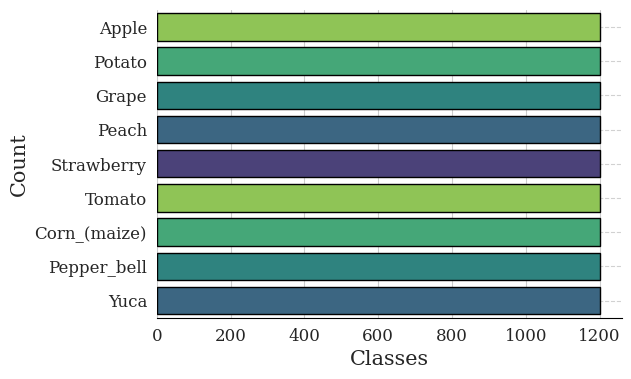

In [24]:
sns.set_style("whitegrid")
fig, ax = plt.subplots(figsize = (6, 4))

for i in ['top', 'right', 'left']:
    ax.spines[i].set_visible(False)
ax.spines['bottom'].set_color('black')

sns.countplot(train.Planta, edgecolor = 'black',
              palette = reversed(sns.color_palette("viridis", 5)))
plt.xlabel('Classes', fontfamily = 'serif', size = 15)
plt.ylabel('Count', fontfamily = 'serif', size = 15)
plt.xticks(fontfamily = 'serif', size = 12)
plt.yticks(fontfamily = 'serif', size = 12)
ax.grid(axis = 'y', linestyle = '--', alpha = 0.9)
plt.show()

### 3.4. Conteo de imágenes por en el conjunto test por categoría

In [27]:
test.Planta.value_counts()

Planta
Apple           300
Peach           300
Yuca            300
Pepper_bell     300
Potato          300
Corn_(maize)    300
Grape           300
Tomato          300
Strawberry      300
Name: count, dtype: int64

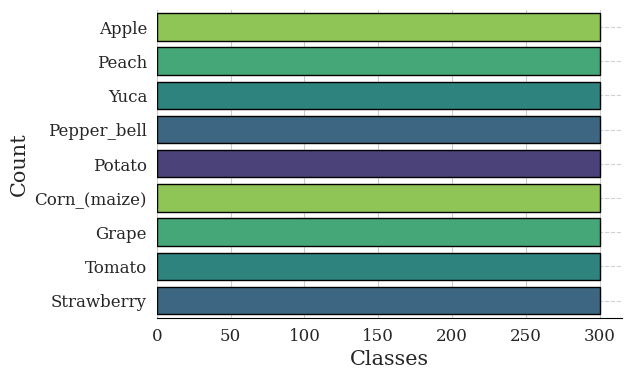

In [29]:
sns.set_style("whitegrid")
fig, ax = plt.subplots(figsize = (6, 4))

for i in ['top', 'right', 'left']:
    ax.spines[i].set_visible(False)
ax.spines['bottom'].set_color('black')

sns.countplot(test.Planta, edgecolor = 'black',
              palette = reversed(sns.color_palette("viridis", 5)))
plt.xlabel('Classes', fontfamily = 'serif', size = 15)
plt.ylabel('Count', fontfamily = 'serif', size = 15)
plt.xticks(fontfamily = 'serif', size = 12)
plt.yticks(fontfamily = 'serif', size = 12)
ax.grid(axis = 'y', linestyle = '--', alpha = 0.9)
plt.show()

### 3.5. Muestra de Imagenes

In [32]:
# Cambiar el nombre de la columna
test = test.rename(columns={'Nombre del archivo': 'image_id'})
train = train.rename(columns={'Nombre del archivo': 'image_id'})

In [34]:
train.head()

,Carpeta,image_id,Planta,Condición,Saludable,Planta_Estado
40101,Apple___Black_rot,4eeaca51-3ca2-4afe-884a-d65c2e31e452___JR_FrgE...,Apple,Black_rot,NO,Apple_sick
39787,Apple___Black_rot,7f421e23-fede-4111-b6ab-cca2474f7d0e___JR_FrgE...,Apple,Black_rot,NO,Apple_sick
1863,Potato___Early_blight,86e98583-f506-4cb7-ba11-eea466662ec7___RS_Earl...,Potato,Early_blight,NO,Potato_sick
863,Grape___Black_rot,a0de02db-e650-4e6e-81cd-752918ba93c3___FAM_B.R...,Grape,Black_rot,NO,Grape_sick
35515,Peach___Bacterial_spot,fe4de6f6-e446-479e-bdba-a320dbdb8fc6___Rut._Ba...,Peach,Bacterial_spot,NO,Peach_sick


#### Plantas Healthy

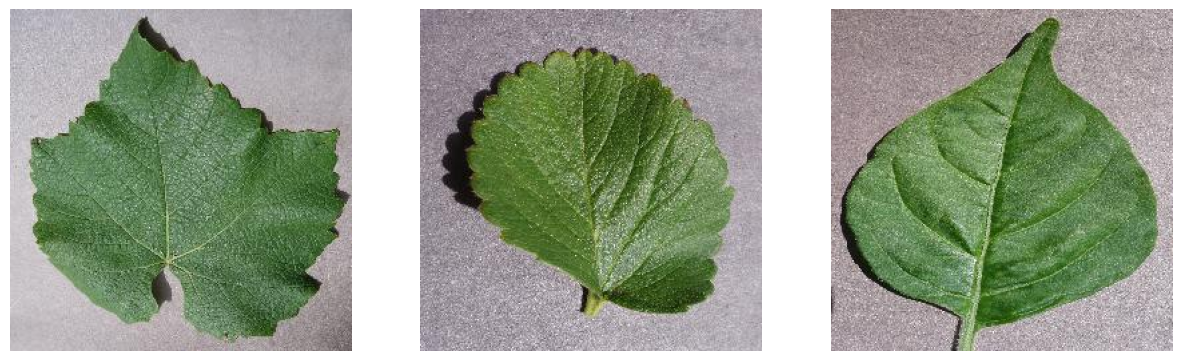

In [37]:
# Seleccionar 3 muestras de la clase "Healthy"
sample = train[train.Saludable == "SI"].sample(3)

# Tamaño de la figura
plt.figure(figsize=(15, 5))

# Carpeta donde están las imágenes
image_folder = "Datos Finales"

for ind, (image_id, Planta) in enumerate(zip(sample.image_id, sample.Planta)):
    plt.subplot(1, 3, ind + 1)

    # Construir la ruta completa de la imagen
    image_path = os.path.join(image_folder, image_id)

    # Cargar la imagen correctamente
    img = cv2.imread(image_path)

    # Verificar si la imagen se cargó correctamente
    if img is None:
        print(f"Error al cargar la imagen: {image_path}")
        continue

    # Convertir la imagen de BGR a RGB
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # Mostrar la imagen
    plt.imshow(img)
    plt.axis("off")

plt.show()

#### Plantas con alguna enfermedad

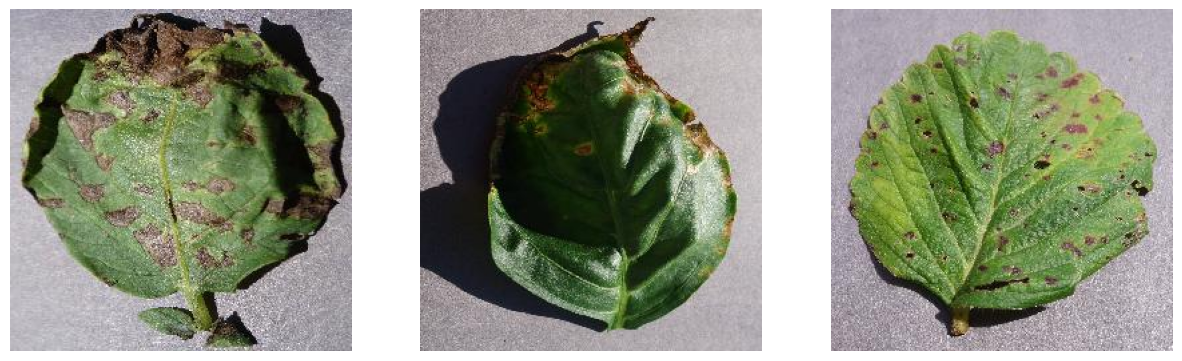

In [40]:
# Seleccionar 3 muestras de la clase "Healthy"
sample = train[train.Saludable == "NO"].sample(3)

# Tamaño de la figura
plt.figure(figsize=(15, 5))

# Carpeta donde están las imágenes
image_folder = "Datos Finales"

for ind, (image_id, Planta) in enumerate(zip(sample.image_id, sample.Planta)):
    plt.subplot(1, 3, ind + 1)

    # Construir la ruta completa de la imagen
    image_path = os.path.join(image_folder, image_id)

    # Cargar la imagen correctamente
    img = cv2.imread(image_path)

    # Verificar si la imagen se cargó correctamente
    if img is None:
        print(f"Error al cargar la imagen: {image_path}")
        continue

    # Convertir la imagen de BGR a RGB
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # Mostrar la imagen
    plt.imshow(img)
    plt.axis("off")

plt.show()

Obtener el tamaño de las imágenes

In [43]:
image_path = os.path.join(image_folder, image_id)

# Definir la carpeta con las imágenes
image_folder = "Datos Finales"

# Función para obtener el tamaño de una imagen
def get_image_size(image_path):
    try:
        with Image.open(image_path) as img:
            return img.size  # Devuelve (ancho, alto)
    except Exception as e:
        print(f"Error con la imagen {image_path}: {e}")
        return None, None

In [45]:
# Obtener el tamaño de cada imagen y agregarlo al DataFrame
widths = []
heights = []

for img_name in train["image_id"]:  # Asegúrate de que la columna se llama "image_id"
    img_path = os.path.join(image_folder, img_name)
    width, height = get_image_size(img_path)
    widths.append(width)
    heights.append(height)

train["width"] = widths
train["height"] = heights

# Mostrar las primeras filas con los nuevos datos
print(train.head())

Error con la imagen Datos Finales/d46fe184-72f6-4b05-8376-b6e17edc5458___RS_NLB  4671.JPG: [Errno 2] No such file or directory: '/Users/mfia/Documents/MFIA - PUJ - Maestría/Proyecto de Grado/0. Data/Datos Finales/d46fe184-72f6-4b05-8376-b6e17edc5458___RS_NLB\xa0 4671.JPG'
Error con la imagen Datos Finales/571927a9-3b0a-4c5e-be0b-a3c9859d66fa___RS_NLB  4443 copy 3.jpg: [Errno 2] No such file or directory: '/Users/mfia/Documents/MFIA - PUJ - Maestría/Proyecto de Grado/0. Data/Datos Finales/571927a9-3b0a-4c5e-be0b-a3c9859d66fa___RS_NLB\xa0 4443 copy 3.jpg'
Error con la imagen Datos Finales/f0b49686-1a0f-4c01-9b60-e816c513215f___RS_NLB  4506 copy.jpg: [Errno 2] No such file or directory: '/Users/mfia/Documents/MFIA - PUJ - Maestría/Proyecto de Grado/0. Data/Datos Finales/f0b49686-1a0f-4c01-9b60-e816c513215f___RS_NLB\xa0 4506 copy.jpg'
Error con la imagen Datos Finales/archivos_plantvillage.csv: cannot identify image file '/Users/mfia/Documents/MFIA - PUJ - Maestría/Proyecto de Grado/0.

## 4. Preparación del Modelo

* Se implementará data augmentation para mejorar la generalización.
* Se evaluará el modelo con métricas como precisión y recall.

In [47]:
# Hiperparámetros principales
BATCH_SIZE = 8
STEPS_PER_EPOCH = len(train)*0.8 / BATCH_SIZE
VALIDATION_STEPS = len(train)*0.2 / BATCH_SIZE
EPOCHS = 8
TARGET_SIZE = 150

In [48]:
train.Planta = train.Planta.astype('str')

train_datagen = ImageDataGenerator(validation_split = 0.2,
                                     preprocessing_function = None,
                                     rotation_range = 45,
                                     zoom_range = 0.2,
                                     horizontal_flip = True,
                                     vertical_flip = True,
                                     fill_mode = 'nearest',
                                     shear_range = 0.1,
                                     height_shift_range = 0.1,
                                     width_shift_range = 0.1)

train_generator = train_datagen.flow_from_dataframe(train,
                         directory = "Datos Finales",
                         subset = "training",
                         x_col = "image_id",
                         y_col = "Planta",
                         target_size = (TARGET_SIZE, TARGET_SIZE),
                         batch_size = BATCH_SIZE,
                         class_mode = "categorical")


validation_datagen = ImageDataGenerator(validation_split = 0.2)

validation_generator = validation_datagen.flow_from_dataframe(train,
                         directory = "Datos Finales",
                         subset = "validation",
                         x_col = "image_id",
                         y_col = "Planta",
                         target_size = (TARGET_SIZE, TARGET_SIZE),
                         batch_size = BATCH_SIZE,
                         class_mode = "categorical")

Found 8633 validated image filenames belonging to 9 classes.
Found 2158 validated image filenames belonging to 9 classes.


Imágen Aleatoria antes de Augmentation

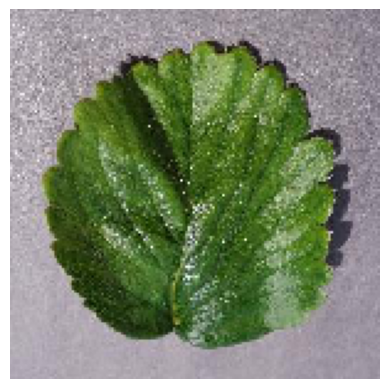

In [63]:
img_path = os.path.join("Datos Finales", train.image_id[2])
img = image.load_img(img_path, target_size = (TARGET_SIZE, TARGET_SIZE))
img_tensor = image.img_to_array(img)
img_tensor = np.expand_dims(img_tensor, axis = 0)
img_tensor /= 255.

plt.imshow(img_tensor[0])
plt.axis('off')
plt.show()

In [65]:
generator = train_datagen.flow_from_dataframe(train.iloc[20:21],
                         directory = "Datos Finales",
                         x_col = "image_id",
                         y_col = "Planta",
                         target_size = (TARGET_SIZE, TARGET_SIZE),
                         batch_size = BATCH_SIZE,
                         class_mode = "categorical")

aug_images = [generator[0][0][0]/255 for i in range(10)]
fig, axes = plt.subplots(2, 5, figsize = (TARGET_SIZE, TARGET_SIZE))
axes = axes.flatten()
for img, ax in zip(aug_images, axes):
    ax.imshow(img)
    ax.axis('off')
plt.tight_layout()
plt.show()

Found 1 validated image filenames belonging to 1 classes.


## 5. Construcción del Modelo

### 5.1. Clasificador

**Arquitectura del Modelo CNN**
El modelo es una red neuronal convolucional (**CNN**) diseñada para clasificar imágenes de plantas en distintas categorías. Su arquitectura incluye:

**1. Capas Convolucionales y de MaxPooling**
Cada capa convolucional extrae características de las imágenes, mientras que **MaxPooling** reduce la dimensionalidad, mejorando la eficiencia del modelo.

- **Capa 1:**  
  - `Conv2D(32, (3,3), activation='relu', input_shape=(150,150,3))`  
  - `BatchNormalization()`
  - `MaxPooling2D(2,2)`

- **Capa 2:**  
  - `Conv2D(64, (3,3), activation='relu')`  
  - `BatchNormalization()`
  - `MaxPooling2D(2,2)`

- **Capa 3:**  
  - `Conv2D(128, (3,3), activation='relu')`  
  - `BatchNormalization()`
  - `MaxPooling2D(2,2)`

- **Capa 4:**  
  - `Conv2D(128, (3,3), activation='relu')`  
  - `BatchNormalization()`
  - `MaxPooling2D(2,2)`

**2. Capa de Aplanamiento**
Después de las capas convolucionales, se usa `Flatten()` para convertir la salida en un vector de una dimensión.

**3. Capas Densas y Regularización**
- Una capa densa con **512 neuronas** y función de activación ReLU.
- Se usa **Dropout (0.5)** para reducir el sobreajuste.
  
**4. Capa de Salida**
- `Dense(9, activation='softmax')`  
- La activación **softmax** se usa porque se trata de un problema de clasificación multiclase (9 categorías).

In [69]:
# Arquitectura del modelo CNN
model = models.Sequential()

# Capa 1: Convolucional y MaxPooling
model.add(layers.Conv2D(32, (3, 3), activation='relu', input_shape=(150, 150, 3)))
model.add(layers.BatchNormalization())
model.add(layers.MaxPooling2D(2, 2))

# Capa 2: Convolucional y MaxPooling
model.add(layers.Conv2D(64, (3, 3), activation='relu'))
model.add(layers.BatchNormalization())
model.add(layers.MaxPooling2D(2, 2))

# Capa 3: Convolucional y MaxPooling
model.add(layers.Conv2D(128, (3, 3), activation='relu'))
model.add(layers.BatchNormalization())
model.add(layers.MaxPooling2D(2, 2))

# Capa 4: Convolucional y MaxPooling
model.add(layers.Conv2D(128, (3, 3), activation='relu'))
model.add(layers.BatchNormalization())
model.add(layers.MaxPooling2D(2, 2))

# Aplanamiento de la capa convolucional
model.add(layers.Flatten())

# Clasificador
model.add(layers.Dense(512, activation='relu'))
model.add(layers.Dropout(0.5))  # Dropout para evitar el overfitting

# Capa de salida
model.add(layers.Dense(9, activation='softmax'))  

### 5.2. Compilación del modelo

In [72]:
model.compile(
    loss='categorical_crossentropy',  # Cambiado a 'categorical_crossentropy' para múltiples clases
    optimizer='adam',
    metrics=['accuracy']
)

In [74]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 148, 148, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 72, 72, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 34, 34, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 34, 34, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 15, 15, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 15, 15, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     3,211,776 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 9)              │         4,617 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,458,633 (13.19 MB)

 Trainable params: 3,457,929 (13.19 MB)

 Non-trainable params: 704 (2.75 KB)

## 6. Ejecución del modelo

* Se entrenará el modelo utilizando Adam como optimizador y EarlyStopping para prevenir sobreajuste.
* Se evaluará el desempeño sobre el conjunto de prueba.

In [77]:
early_stopping = EarlyStopping(
    monitor='val_loss',  # Monitor the validation loss
    patience=5,  # Number of epochs with no improvement after which training will be stopped
    restore_best_weights=True  # Restore the model weights from the epoch with the best value of the monitored quantity
)

from tensorflow.keras.callbacks import ReduceLROnPlateau

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2,  # Reduce learning rate by a factor of 0.2
    patience=3,  # Number of epochs with no improvement after which learning rate will be reduced
    min_lr=1e-5  # Minimum learning rate
)

In [79]:
history = model.fit(
    train_generator,
    epochs=EPOCHS,
    validation_data=validation_generator,
    callbacks=[early_stopping, reduce_lr],
    verbose=2
)

Epoch 1/8
1080/1080 - 130s - 121ms/step - accuracy: 0.4434 - loss: 2.1789 - val_accuracy: 0.4467 - val_loss: 1.7965 - learning_rate: 0.0010
Epoch 2/8
1080/1080 - 139s - 129ms/step - accuracy: 0.5485 - loss: 1.3386 - val_accuracy: 0.6256 - val_loss: 1.1759 - learning_rate: 0.0010
Epoch 3/8
1080/1080 - 144s - 133ms/step - accuracy: 0.6011 - loss: 1.1970 - val_accuracy: 0.7553 - val_loss: 0.7257 - learning_rate: 0.0010
Epoch 4/8
1080/1080 - 147s - 136ms/step - accuracy: 0.6461 - loss: 1.0857 - val_accuracy: 0.7470 - val_loss: 0.7196 - learning_rate: 0.0010
Epoch 5/8
1080/1080 - 147s - 136ms/step - accuracy: 0.6703 - loss: 0.9925 - val_accuracy: 0.7224 - val_loss: 0.8277 - learning_rate: 0.0010
Epoch 6/8
1080/1080 - 147s - 136ms/step - accuracy: 0.7062 - loss: 0.8977 - val_accuracy: 0.6710 - val_loss: 1.3084 - learning_rate: 0.0010
Epoch 7/8
1080/1080 - 146s - 135ms/step - accuracy: 0.7298 - loss: 0.8212 - val_accuracy: 0.7493 - val_loss: 0.7711 - learning_rate: 0.0010
Epoch 8/8
1080/1080 

### 6.1. Resultados del Modelo

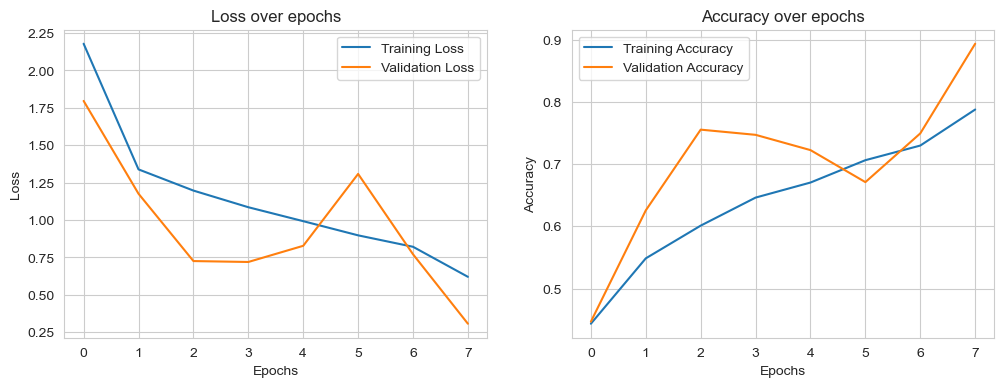

In [81]:
# Acceder a los datos de pérdida y precisión
loss = history.history['loss']
val_loss = history.history['val_loss']
accuracy = history.history['accuracy']
val_accuracy = history.history['val_accuracy']

# Graficar la pérdida del modelo
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss over epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

# Graficar la precisión del modelo
plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy over epochs')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

In [83]:
epochs= list(range(1, EPOCHS + 1))
print(epochs)
data = {
    'Epoch': epochs,
    'Trainning Loss': loss,
    'Validation Loss': val_loss,
    'Training Accuracy': accuracy,
    'Validation  Accuracy': val_accuracy
}
df = pd.DataFrame(data)

# Imprimir la tabla
print(df)

[1, 2, 3, 4, 5, 6, 7, 8]
   Epoch  Trainning Loss  Validation Loss  Training Accuracy  \
0      1        2.178880         1.796493           0.443415   
1      2        1.338624         1.175896           0.548477   
2      3        1.196973         0.725694           0.601066   
3      4        1.085658         0.719598           0.646125   
4      5        0.992475         0.827713           0.670335   
5      6        0.897661         1.308357           0.706243   
6      7        0.821198         0.771121           0.729758   
7      8        0.620278         0.306767           0.787675   

   Validation  Accuracy  
0              0.446710  
1              0.625579  
2              0.755329  
3              0.746988  
4              0.722428  
5              0.670992  
6              0.749305  
7              0.893420  


In [84]:
# Accuracy final en entrenamiento
val_loss = history.history['val_loss'][-1]

In [85]:
print('Perdida final en Train:', history.history['loss'][-1])
print("Pérdida final en Validation:", history.history['val_loss'][-1])


print("Accuracy final en Train:", history.history['accuracy'][-1])
print("Accuracy final en Validation:", history.history['val_accuracy'][-1])

Perdida final en Train: 0.6202778816223145
Pérdida final en Validation: 0.3067671060562134
Accuracy final en Train: 0.7876752018928528
Accuracy final en Validation: 0.8934198617935181


## 7. Evaluación del Modelo

### 7.1. Lote de imagenes de testeo

In [89]:
from sklearn.metrics import confusion_matrix, accuracy_score, ConfusionMatrixDisplay

In [90]:
fin = datetime.datetime.now()
print(f"Fin: {fin.strftime('%Y-%m-%d %H:%M:%S.%f')}")
    
duracion = fin - inicio
print(f"Duración: {duracion}")

Fin: 2025-04-04 17:06:31.616740
Duración: 0:21:11.801658


In [91]:
test.Planta = test.Planta.astype('str')

test_generator =  train_datagen.flow_from_dataframe(test,
                         directory = "Datos Finales",
                         subset = "training",
                         x_col = "image_id",
                         y_col = "Planta",
                         target_size = (TARGET_SIZE, TARGET_SIZE),
                         batch_size = BATCH_SIZE,
                         class_mode = "categorical")

Found 2160 validated image filenames belonging to 9 classes.


### 7.2. Predicciones con imagenes de Testeo

In [93]:
# -------------------------
# 1. Obtener predicciones completas para test
# -------------------------
y_pred_probs = model.predict(test_generator)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = test_generator.classes

270/270 ━━━━━━━━━━━━━━━━━━━━ 10s 37ms/step


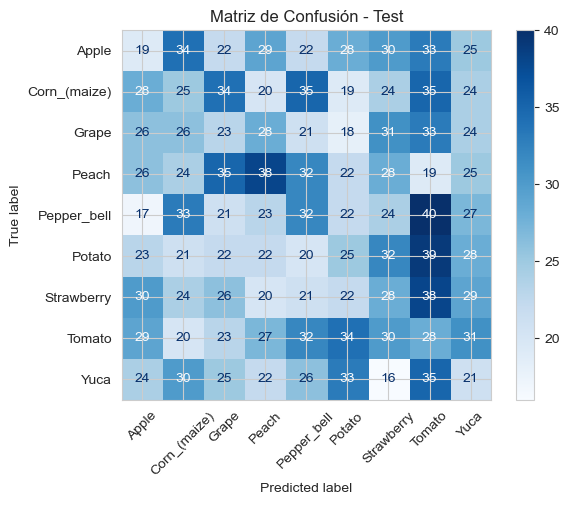

In [94]:
# -------------------------
# 2. Matriz de Confusión
# -------------------------
cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=test_generator.class_indices.keys())
disp.plot(cmap="Blues", xticks_rotation=45)
plt.title("Matriz de Confusión - Test")
plt.show()


### 7.3. Presición de la Predicción

In [97]:
accuracy = accuracy_score(y_true, y_pred)
print(f"Test Accuracy: {accuracy:.4f}")

Test Accuracy: 0.1106


### 7.4. Muestreo visual de predicciones vs etiquetas reales


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step


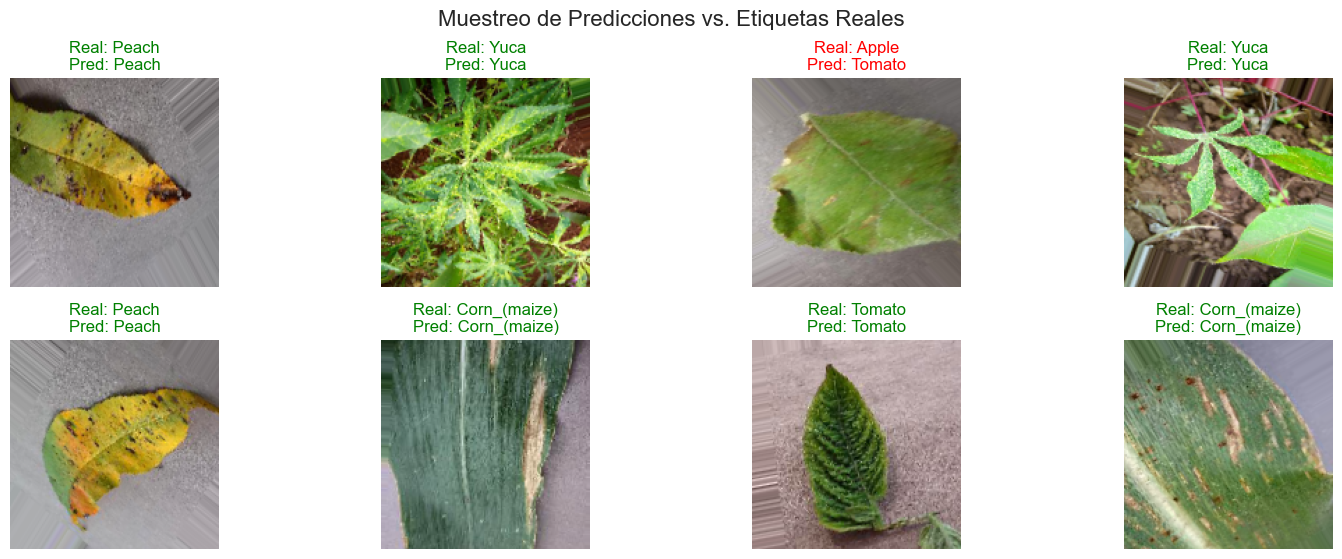

In [99]:
# Función para normalizar imágenes solo para visualización
def normalize_for_display(img):
    img_min = img.min()
    img_max = img.max()
    if img_max > 1.0 or img_min < 0.0:
        img = (img - img_min) / (img_max - img_min + 1e-7)
    return img

# Obtener nombres de clases
class_indices = test_generator.class_indices
class_names = list(class_indices.keys())

# Reiniciar el generador para empezar desde el principio
test_generator.reset()
x_batch, y_true_batch = next(test_generator)

# Obtener predicciones del modelo
y_pred_probs_batch = model.predict(x_batch)
y_pred_batch = np.argmax(y_pred_probs_batch, axis=1)
y_true_batch = np.argmax(y_true_batch, axis=1)

# Número de imágenes a mostrar (máximo el tamaño del batch)
num_samples = x_batch.shape[0]

# Mostrar imágenes con etiquetas
plt.figure(figsize=(15, 8))
for i in range(num_samples):
    plt.subplot(3, 4, i + 1)
    img_to_show = normalize_for_display(x_batch[i])
    plt.imshow(img_to_show)
    plt.axis('off')
    plt.title(
        f"Real: {class_names[y_true_batch[i]]}\nPred: {class_names[y_pred_batch[i]]}",
        color='green' if y_true_batch[i] == y_pred_batch[i] else 'red'
    )
plt.tight_layout()
plt.suptitle("Muestreo de Predicciones vs. Etiquetas Reales", fontsize=16, y=1.02)
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step


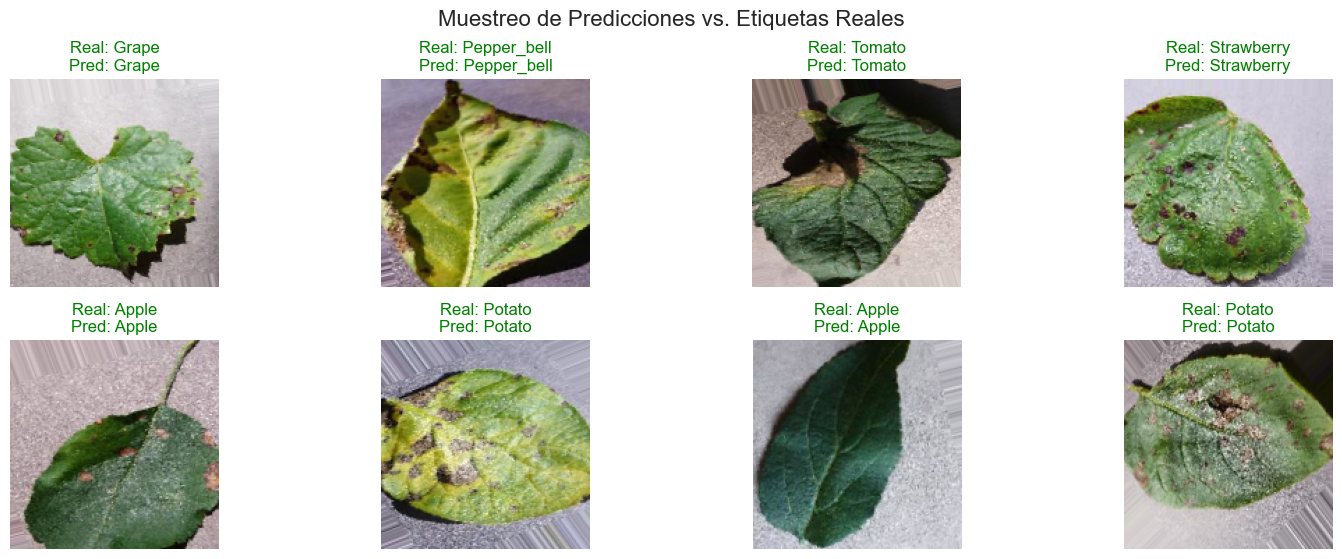

In [100]:
# Función para normalizar imágenes solo para visualización
def normalize_for_display(img):
    img_min = img.min()
    img_max = img.max()
    if img_max > 1.0 or img_min < 0.0:
        img = (img - img_min) / (img_max - img_min + 1e-7)
    return img

# Obtener nombres de clases
class_indices = test_generator.class_indices
class_names = list(class_indices.keys())

# Reiniciar el generador para empezar desde el principio
test_generator.reset()
x_batch, y_true_batch = next(test_generator)

# Obtener predicciones del modelo
y_pred_probs_batch = model.predict(x_batch)
y_pred_batch = np.argmax(y_pred_probs_batch, axis=1)
y_true_batch = np.argmax(y_true_batch, axis=1)

# Número de imágenes a mostrar (máximo el tamaño del batch)
num_samples = x_batch.shape[0]

# Mostrar imágenes con etiquetas
plt.figure(figsize=(15, 8))
for i in range(num_samples):
    plt.subplot(3, 4, i + 1)
    img_to_show = normalize_for_display(x_batch[i])
    plt.imshow(img_to_show)
    plt.axis('off')
    plt.title(
        f"Real: {class_names[y_true_batch[i]]}\nPred: {class_names[y_pred_batch[i]]}",
        color='green' if y_true_batch[i] == y_pred_batch[i] else 'red'
    )
plt.tight_layout()
plt.suptitle("Muestreo de Predicciones vs. Etiquetas Reales", fontsize=16, y=1.02)
plt.show()

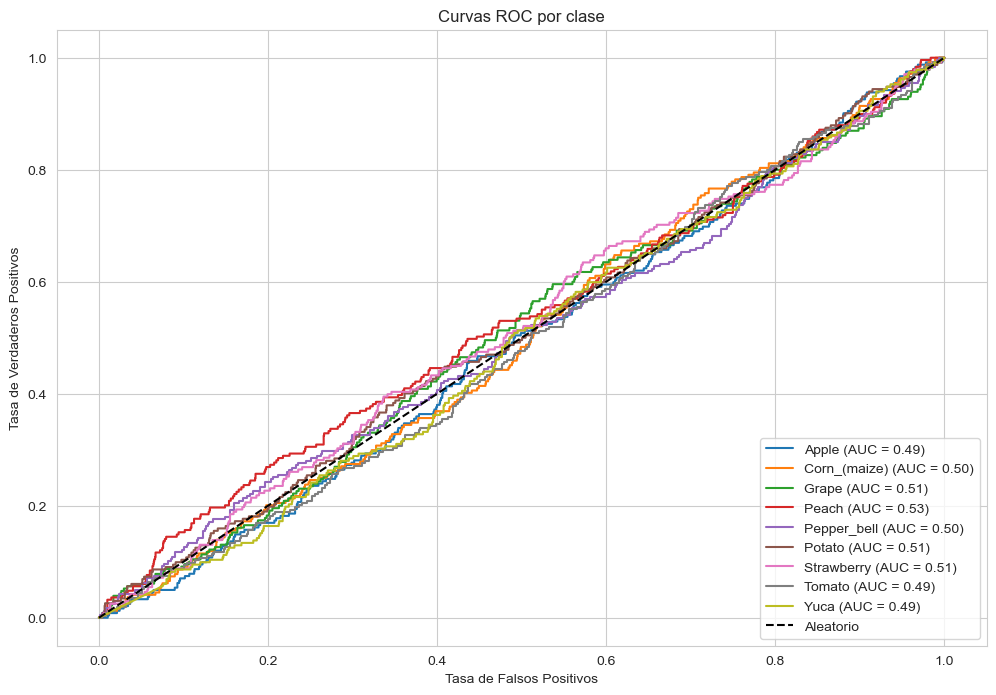

In [101]:
from sklearn.metrics import roc_curve, auc
from tensorflow.keras.utils import to_categorical

# 3. Convertir etiquetas reales a one-hot
n_classes = y_pred_probs.shape[1]
y_true_onehot = to_categorical(y_true, num_classes=n_classes)

# 4. Calcular ROC y AUC por clase
fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_true_onehot[:, i], y_pred_probs[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# 5. Obtener nombres de clase
class_names = list(test_generator.class_indices.keys())

# 6. Graficar curvas ROC
plt.figure(figsize=(12, 8))
for i in range(n_classes):
    plt.plot(fpr[i], tpr[i], label=f'{class_names[i]} (AUC = {roc_auc[i]:.2f})')

plt.plot([0, 1], [0, 1], 'k--', label='Aleatorio')
plt.xlabel('Tasa de Falsos Positivos')
plt.ylabel('Tasa de Verdaderos Positivos')
plt.title('Curvas ROC por clase')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

In [102]:
from sklearn.metrics import roc_auc_score

# AUC macro (promedio de clases, todas igual de importantes)
auc_macro = roc_auc_score(y_true_onehot, y_pred_probs, average='macro')

# AUC micro (promedia sobre todas las instancias)
auc_micro = roc_auc_score(y_true_onehot, y_pred_probs, average='micro')

print(f"AUC Macro promedio: {auc_macro:.4f}")
print(f"AUC Micro promedio: {auc_micro:.4f}")


AUC Macro promedio: 0.5019
AUC Micro promedio: 0.5027


In [130]:
from sklearn.metrics import accuracy_score, f1_score, classification_report

# Asegúrate de tener esto:
# y_pred = np.argmax(y_pred_probs, axis=1)
# y_true = test_generator.classes

# Accuracy
accuracy = accuracy_score(y_true, y_pred)

# F1 Scores
f1_macro = f1_score(y_true, y_pred, average='macro')
f1_micro = f1_score(y_true, y_pred, average='micro')
f1_weighted = f1_score(y_true, y_pred, average='weighted')

print(f"Accuracy: {accuracy:.4f}")
print(f"F1 Score (macro): {f1_macro:.4f}")
print(f"F1 Score (micro): {f1_micro:.4f}")
print(f"F1 Score (weighted): {f1_weighted:.4f}")

# Detalle por clase
class_names = list(test_generator.class_indices.keys())
print("\nReporte de clasificación por clase:")
print(classification_report(y_true, y_pred, target_names=class_names))

Accuracy: 0.1106
F1 Score (macro): 0.1106
F1 Score (micro): 0.1106
F1 Score (weighted): 0.1108

Reporte de clasificación por clase:
              precision    recall  f1-score   support

       Apple       0.09      0.08      0.08       242
Corn_(maize)       0.11      0.10      0.10       244
       Grape       0.10      0.10      0.10       230
       Peach       0.17      0.15      0.16       249
 Pepper_bell       0.13      0.13      0.13       239
      Potato       0.11      0.11      0.11       232
  Strawberry       0.12      0.12      0.12       238
      Tomato       0.09      0.11      0.10       254
        Yuca       0.09      0.09      0.09       232

    accuracy                           0.11      2160
   macro avg       0.11      0.11      0.11      2160
weighted avg       0.11      0.11      0.11      2160

